# Variational Quantum Classifier
## Objectives achieved
1. Data leakage eliminated (scaler fit on train only)
2. Deeper variational ansatz with entangling layers
3. Multi-qubit measurement with parity-based output
4. Parameter-shift rule replaces noisy finite differences
5. Random parameter initialization
6. Backend reused across circuit executions
7. Training data shuffled each epoch
8. Redundant circuit calls removed from gradient
9. Comprehensive metrics: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix, Training Curves
10. Fair classical baselines with cross-validation

## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Load Data ---
file_path = 'pulsar_stars.csv'

# Standard column names for the HTRU2 Pulsar dataset
col_names = [
    'Mean of the integrated profile', 
    'Standard deviation of the integrated profile', 
    'Excess kurtosis of the integrated profile', 
    'Skewness of the integrated profile', 
    'Mean of the DM-SNR curve', 
    'Standard deviation of the DM-SNR curve', 
    'Excess kurtosis of the DM-SNR curve', 
    'Skewness of the DM-SNR curve', 
    'target_class'
]

try:
    df = pd.read_csv(file_path, names=col_names, header=None)
except FileNotFoundError:
    print(f"Error: '{file_path}' not found.")
    raise SystemExit

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['target_class'].value_counts()}")
print(f"\nClass imbalance ratio: {df['target_class'].value_counts()[0] / df['target_class'].value_counts()[1]:.1f}:1")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\n--- Statistical Summary ---")
print(df.describe())

Dataset shape: (17898, 9)

Class distribution:
target_class
0    16259
1     1639
Name: count, dtype: int64

Class imbalance ratio: 9.9:1

Missing values: 0

--- Statistical Summary ---
       Mean of the integrated profile  \
count                    17898.000000   
mean                       111.079968   
std                         25.652935   
min                          5.812500   
25%                        100.929688   
50%                        115.078125   
75%                        127.085938   
max                        192.617188   

       Standard deviation of the integrated profile  \
count                                  17898.000000   
mean                                      46.549532   
std                                        6.843189   
min                                       24.772042   
25%                                       42.376018   
50%                                       46.947479   
75%                                       51.023202   
max 

## 2. Data Visualization

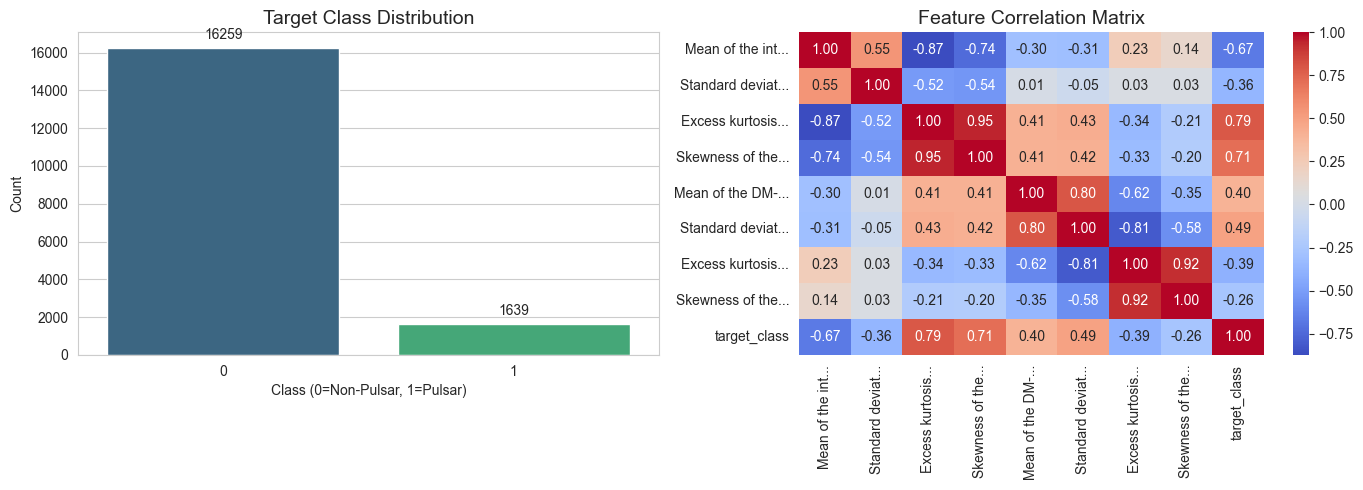

In [2]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax = sns.countplot(x='target_class', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Target Class Distribution', fontsize=14)
axes[0].set_xlabel('Class (0=Non-Pulsar, 1=Pulsar)')
axes[0].set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

# FIX: numeric_only=True for df.corr()
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1],
            xticklabels=[c[:15] + '...' if len(c) > 15 else c for c in correlation_matrix.columns],
            yticklabels=[c[:15] + '...' if len(c) > 15 else c for c in correlation_matrix.columns])
axes[1].set_title('Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()

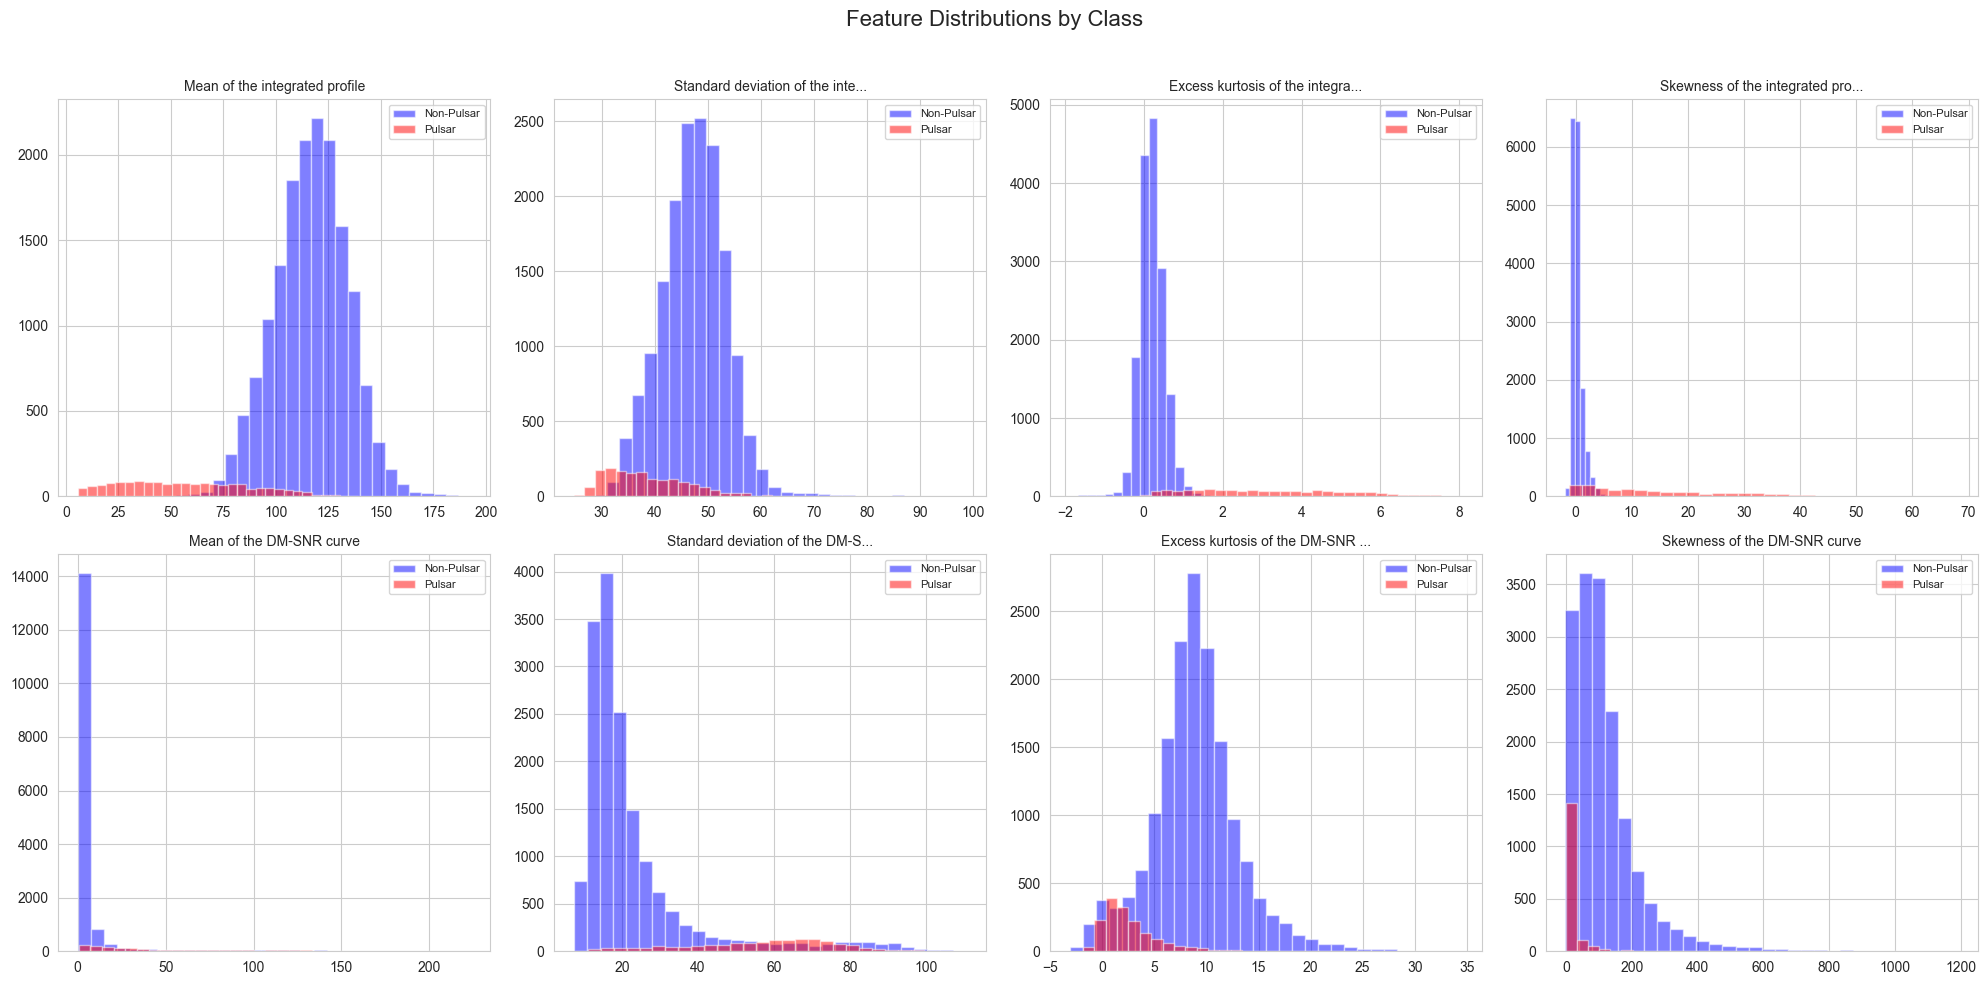

In [3]:
# Feature distributions by class
feature_cols = [c for c in df.columns if c != 'target_class']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    df[df['target_class'] == 0][col].hist(bins=30, alpha=0.5, ax=axes[i], color='blue', label='Non-Pulsar')
    df[df['target_class'] == 1][col].hist(bins=30, alpha=0.5, ax=axes[i], color='red', label='Pulsar')
    axes[i].set_title(col[:30] + ('...' if len(col) > 30 else ''), fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Class', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 3. Data Preparation


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Balanced subset
pulsars = df[df['target_class'] == 1]
non_pulsars = df[df['target_class'] == 0].sample(n=len(pulsars), random_state=42)
df_balanced = pd.concat([pulsars, non_pulsars]).sample(frac=1, random_state=42).reset_index(drop=True)

X_all = df_balanced.drop('target_class', axis=1).values
Y_all = df_balanced['target_class'].values

#Split FIRST, then scale
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_all, Y_all, test_size=0.3, random_state=42, stratify=Y_all
)

#Fit scaler on training data ONLY, then transform both
scaler = MinMaxScaler(feature_range=(0, np.pi))  # Scale to [0, pi] for rotation angles
scaler.fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")
print(f"Features:     {X_train_scaled.shape[1]}")
print(f"Train class balance: {np.bincount(Y_train.astype(int))}")
print(f"Test class balance:  {np.bincount(Y_test.astype(int))}")

# For the quantum model, use a smaller subset (quantum simulation is slow)
# Increase these for better accuracy at the cost of runtime
Q_TRAIN_SIZE = 80
Q_TEST_SIZE = 40

np.random.seed(42)
train_idx = np.random.choice(len(X_train_scaled), Q_TRAIN_SIZE, replace=False)
test_idx = np.random.choice(len(X_test_scaled), Q_TEST_SIZE, replace=False)

X_train_q = X_train_scaled[train_idx]
Y_train_q = Y_train[train_idx]
X_test_q = X_test_scaled[test_idx]
Y_test_q = Y_test[test_idx]

print(f"\nQuantum subset — Train: {Q_TRAIN_SIZE}, Test: {Q_TEST_SIZE}")
print(f"Quantum train class balance: {np.bincount(Y_train_q.astype(int))}")
print(f"Quantum test class balance:  {np.bincount(Y_test_q.astype(int))}")

Training set: 2294 samples
Test set:     984 samples
Features:     8
Train class balance: [1147 1147]
Test class balance:  [492 492]

Quantum subset — Train: 80, Test: 40
Quantum train class balance: [40 40]
Quantum test class balance:  [17 23]


## 4. Variational Quantum Classifier (Fixed)

**Architectural fixes:**
- **Deeper ansatz**: 2 variational layers, each with Ry + Rz rotations AND CNOT entanglement
- **Multi-qubit measurement**: All qubits measured; prediction = parity of bitstring
- **Parameter-shift rule**: Exact analytic gradients (shift = π/2) instead of noisy finite differences
- **Random initialization**: Parameters drawn from uniform(0, 2π)
- **Backend reuse**: Simulator instantiated once

In [5]:
from qiskit_aer import Aer
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

N_QUBITS = 8       # Number of features = number of qubits
N_LAYERS = 2        # Depth of variational ansatz
SHOTS = 8192        # Measurement shots per circuit
PARAMS_PER_LAYER = N_QUBITS * 2  # Ry + Rz per qubit per layer
N_PARAMS = N_LAYERS * PARAMS_PER_LAYER

# FIX: Create backend ONCE and reuse
BACKEND = Aer.get_backend("qasm_simulator")

print(f"Qubits: {N_QUBITS}")
print(f"Variational layers: {N_LAYERS}")
print(f"Total trainable parameters: {N_PARAMS}")
print(f"Shots per circuit: {SHOTS}")

Qubits: 8
Variational layers: 2
Total trainable parameters: 32
Shots per circuit: 8192


In [6]:
def build_circuit(x, theta):
    """
    Build the full VQC circuit:
      1) Feature map (H + Rz encoding + ZZ entanglement)
      2) Variational ansatz (N_LAYERS of Ry, Rz rotations + CNOT ring)
      3) Measure ALL qubits
    """
    qr = QuantumRegister(N_QUBITS)
    cr = ClassicalRegister(N_QUBITS)  # FIX: Measure ALL qubits
    qc = QuantumCircuit(qr, cr)

    # --- Feature Map (ZZFeatureMap-style) ---
    for i in range(N_QUBITS):
        qc.h(i)
        qc.rz(2.0 * x[i], i)
    for i in range(N_QUBITS - 1):
        qc.cx(i, i + 1)
        qc.rz(2.0 * (np.pi - x[i]) * (np.pi - x[i + 1]), i + 1)
        qc.cx(i, i + 1)

    qc.barrier()

    # --- Variational Ansatz (FIXED: deeper, with entanglement) ---
    idx = 0
    for layer in range(N_LAYERS):
        # Rotation sub-layer: Ry + Rz on each qubit
        for i in range(N_QUBITS):
            qc.ry(theta[idx], i)
            qc.rz(theta[idx + 1], i)
            idx += 2
        # Entangling sub-layer: circular CNOT ring
        for i in range(N_QUBITS):
            qc.cx(i, (i + 1) % N_QUBITS)

    # --- Measure all qubits ---
    qc.measure(qr, cr)
    return qc


def predict_proba(x, theta):
    """
    Run circuit and return P(label=1) using parity of all measured qubits.
    FIX: Uses all qubits instead of just qubit 0.
    """
    qc = build_circuit(x, theta)
    job = BACKEND.run(qc, shots=SHOTS)
    counts = job.result().get_counts(qc)

    # Parity-based output: label=1 if odd number of 1s in bitstring
    p1 = 0
    for bitstring, count in counts.items():
        parity = bitstring.count('1') % 2
        if parity == 1:
            p1 += count
    return p1 / SHOTS


def loss_fn(pred, target):
    """Squared error loss."""
    return (target - pred) ** 2


def parameter_shift_gradient(x, y, theta):
    """
    FIX: Exact analytic gradient using the parameter-shift rule.
    For Ry/Rz gates: df/dtheta = [f(theta + pi/2) - f(theta - pi/2)] / 2
    Then chain through squared-error loss.
    """
    shift = np.pi / 2
    grad = np.zeros_like(theta)

    for i in range(len(theta)):
        theta_plus = theta.copy()    # FIX: use .copy() not copy.copy()
        theta_minus = theta.copy()
        theta_plus[i] += shift
        theta_minus[i] -= shift

        pred_plus = predict_proba(x, theta_plus)
        pred_minus = predict_proba(x, theta_minus)

        # Loss-gradient via shift rule
        grad[i] = (loss_fn(pred_plus, y) - loss_fn(pred_minus, y)) / 2.0

    return grad


def compute_accuracy(X, Y, theta):
    """Compute classification accuracy."""
    correct = 0
    for x_i, y_i in zip(X, Y):
        pred = predict_proba(x_i, theta)
        predicted_label = 1 if pred >= 0.5 else 0
        if predicted_label == int(y_i):
            correct += 1
    return correct / len(Y)


def compute_predictions(X, theta):
    """Get predicted probabilities and labels for a dataset."""
    probs = np.array([predict_proba(x_i, theta) for x_i in X])
    labels = (probs >= 0.5).astype(int)
    return probs, labels


print("Quantum circuit functions defined.")
sample_theta = np.random.uniform(0, 2 * np.pi, N_PARAMS)
sample_circuit = build_circuit(X_train_q[0], sample_theta)
print(f"Example circuit — Gates: {sample_circuit.size()}, Depth: {sample_circuit.depth()}")
print("\nSample quantum circuit:")
print(sample_circuit.draw(output="text"))

Quantum circuit functions defined.
Example circuit — Gates: 93, Depth: 44

Sample quantum circuit:
      ┌───┐ ┌────────────┐                                                 »
q0_0: ┤ H ├─┤ Rz(3.1186) ├───■──────────────────■──────────────────────────»
      ├───┤ ├────────────┤ ┌─┴─┐┌────────────┐┌─┴─┐                        »
q0_1: ┤ H ├─┤ Rz(2.3599) ├─┤ X ├┤ Rz(6.2077) ├┤ X ├──■──────────────────■──»
      ├───┤ ├────────────┤ └───┘└────────────┘└───┘┌─┴─┐┌────────────┐┌─┴─┐»
q0_2: ┤ H ├─┤ Rz(1.4154) ├─────────────────────────┤ X ├┤ Rz(9.5489) ├┤ X ├»
      ├───┤┌┴────────────┤                         └───┘└────────────┘└───┘»
q0_3: ┤ H ├┤ Rz(0.20326) ├─────────────────────────────────────────────────»
      ├───┤├─────────────┴┐                                                »
q0_4: ┤ H ├┤ Rz(0.063967) ├────────────────────────────────────────────────»
      ├───┤└┬────────────┬┘                                                »
q0_5: ┤ H ├─┤ Rz(0.6149) ├────────────────────────────

## 5. Training the VQC

In [7]:
# --- Training Hyperparameters ---
LEARNING_RATE = 0.1
EPOCHS = 15

# FIX: Random initialization instead of all-ones
np.random.seed(42)
theta = np.random.uniform(0, 2 * np.pi, N_PARAMS)

# Tracking
train_losses = []
train_accs = []
test_accs = []

print(f"Training VQC: {EPOCHS} epochs, lr={LEARNING_RATE}, {Q_TRAIN_SIZE} samples")
print(f"{'Epoch':>5} {'Loss':>8} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 38)

for epoch in range(EPOCHS):
    epoch_losses = []

    # FIX: Shuffle training data each epoch
    perm = np.random.permutation(len(X_train_q))
    X_shuffled = X_train_q[perm]
    Y_shuffled = Y_train_q[perm]

    for x_i, y_i in zip(X_shuffled, Y_shuffled):
        pred = predict_proba(x_i, theta)
        epoch_losses.append(loss_fn(pred, y_i))

        # Update with parameter-shift gradient
        grad = parameter_shift_gradient(x_i, y_i, theta)
        theta = theta - LEARNING_RATE * grad

    avg_loss = np.mean(epoch_losses)
    train_losses.append(avg_loss)

    # Compute accuracies (on the small quantum subsets)
    tr_acc = compute_accuracy(X_train_q, Y_train_q, theta)
    te_acc = compute_accuracy(X_test_q, Y_test_q, theta)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    print(f"{epoch:>5d} {avg_loss:>8.4f} {tr_acc:>10.3f} {te_acc:>10.3f}")

print("\nTraining complete!")

Training VQC: 15 epochs, lr=0.1, 80 samples
Epoch     Loss  Train Acc   Test Acc
--------------------------------------
    0   0.2520      0.487      0.500
    1   0.2514      0.450      0.575
    2   0.2506      0.463      0.550
    3   0.2490      0.500      0.575
    4   0.2460      0.512      0.575
    5   0.2450      0.512      0.625
    6   0.2434      0.575      0.450
    7   0.2401      0.588      0.550
    8   0.2389      0.562      0.525
    9   0.2364      0.625      0.500
   10   0.2366      0.562      0.600
   11   0.2343      0.500      0.600
   12   0.2332      0.562      0.475
   13   0.2336      0.625      0.600
   14   0.2336      0.600      0.475

Training complete!


## 6. VQC Evaluation — Full Metrics

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)

# Get predictions on test set
test_probs_q, test_preds_q = compute_predictions(X_test_q, theta)

# --- Compute all metrics ---
vqc_metrics = {
    'Accuracy': accuracy_score(Y_test_q, test_preds_q),
    'Balanced Accuracy': balanced_accuracy_score(Y_test_q, test_preds_q),
    'Precision': precision_score(Y_test_q, test_preds_q, zero_division=0),
    'Recall': recall_score(Y_test_q, test_preds_q, zero_division=0),
    'F1 Score': f1_score(Y_test_q, test_preds_q, zero_division=0),
    'ROC-AUC': roc_auc_score(Y_test_q, test_probs_q),
    'MCC': matthews_corrcoef(Y_test_q, test_preds_q),
}

print("=" * 50)
print("VARIATIONAL QUANTUM CLASSIFIER — TEST RESULTS")
print("=" * 50)
for metric, value in vqc_metrics.items():
    print(f"  {metric:<22s}: {value:.4f}")

print(f"\n--- Classification Report ---")
print(classification_report(Y_test_q, test_preds_q, target_names=['Non-Pulsar', 'Pulsar']))

print("--- Confusion Matrix ---")
cm = confusion_matrix(Y_test_q, test_preds_q)
print(cm)

VARIATIONAL QUANTUM CLASSIFIER — TEST RESULTS
  Accuracy              : 0.5250
  Balanced Accuracy     : 0.5179
  Precision             : 0.5909
  Recall                : 0.5652
  F1 Score              : 0.5778
  ROC-AUC               : 0.5396
  MCC                   : 0.0356

--- Classification Report ---
              precision    recall  f1-score   support

  Non-Pulsar       0.44      0.47      0.46        17
      Pulsar       0.59      0.57      0.58        23

    accuracy                           0.53        40
   macro avg       0.52      0.52      0.52        40
weighted avg       0.53      0.53      0.53        40

--- Confusion Matrix ---
[[ 8  9]
 [10 13]]


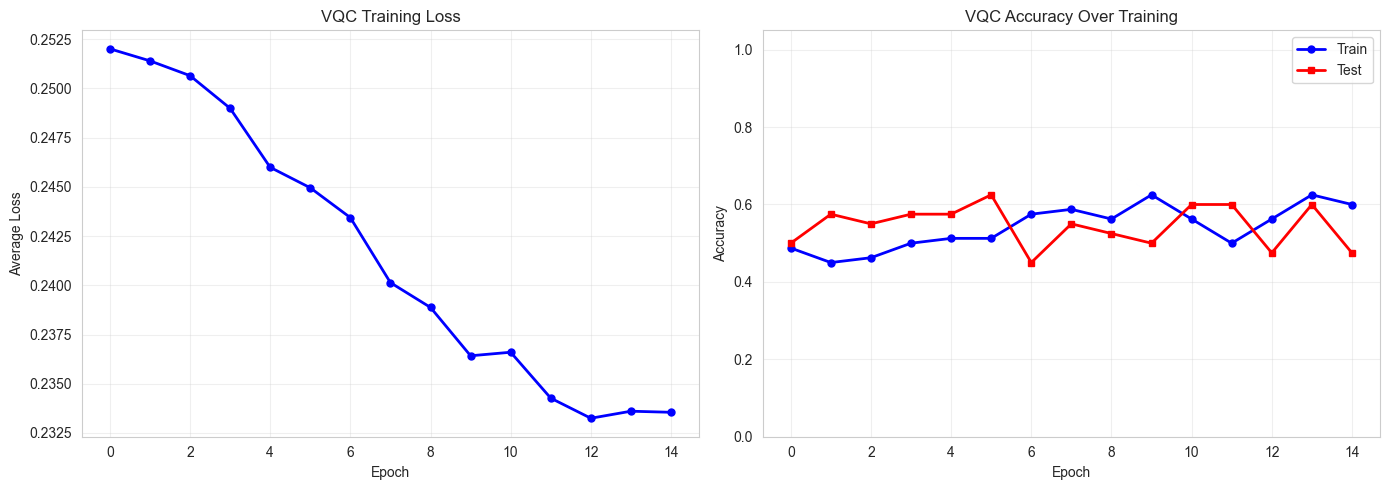

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(range(EPOCHS), train_losses, 'b-o', linewidth=2, markersize=5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Loss')
axes[0].set_title('VQC Training Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(range(EPOCHS), train_accs, 'b-o', linewidth=2, markersize=5, label='Train')
axes[1].plot(range(EPOCHS), test_accs, 'r-s', linewidth=2, markersize=5, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('VQC Accuracy Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 7. Classical Baselines — Fair Comparison

We evaluate classical models on the **same quantum-sized subset** for a fair comparison, and also on the **full balanced dataset** created during preprocessing.

In [10]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score


def evaluate_model(model, X_tr, Y_tr, X_te, Y_te, name):
    """Train, predict, and compute full metrics for a classical model."""
    model.fit(X_tr, Y_tr)
    preds = model.predict(X_te)

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        probs = model.decision_function(X_te)
    else:
        probs = preds.astype(float)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(Y_te, preds),
        'Balanced Accuracy': balanced_accuracy_score(Y_te, preds),
        'Precision': precision_score(Y_te, preds, zero_division=0),
        'Recall': recall_score(Y_te, preds, zero_division=0),
        'F1 Score': f1_score(Y_te, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(Y_te, probs),
        'MCC': matthews_corrcoef(Y_te, preds),
    }
    return metrics, preds, probs


classical_models = {
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

# --- A) Evaluate on the SAME small subset as the quantum model ---
print("=" * 65)
print("CLASSICAL MODELS — SAME SUBSET AS VQC (Fair Comparison)")
print("=" * 65)

small_results = []
for name, model in classical_models.items():
    metrics, _, _ = evaluate_model(model, X_train_q, Y_train_q, X_test_q, Y_test_q, name)
    small_results.append(metrics)

# Add VQC results
vqc_row = {'Model': 'VQC (Ours)', **vqc_metrics}
small_results.append(vqc_row)

df_small = pd.DataFrame(small_results).set_index('Model')
print(df_small.round(4).to_string())


# --- B) Evaluate on the full balanced dataset ---
print("\n" + "=" * 65)
print("CLASSICAL MODELS — FULL BALANCED DATASET")
print("=" * 65)

full_results = []
for name, model in classical_models.items():
    metrics, _, _ = evaluate_model(model, X_train_scaled, Y_train, X_test_scaled, Y_test, name)
    full_results.append(metrics)

df_full = pd.DataFrame(full_results).set_index('Model')
print(df_full.round(4).to_string())

CLASSICAL MODELS — SAME SUBSET AS VQC (Fair Comparison)
                     Accuracy  Balanced Accuracy  Precision  Recall  F1 Score  ROC-AUC     MCC
Model                                                                                         
SVM (RBF)               0.825             0.8325     0.9000  0.7826    0.8372   0.9233  0.6574
Random Forest           0.825             0.8171     0.8333  0.8696    0.8511   0.9143  0.6400
Gradient Boosting       0.825             0.8171     0.8333  0.8696    0.8511   0.8824  0.6400
Logistic Regression     0.875             0.8760     0.9091  0.8696    0.8889   0.9233  0.7472
K-Nearest Neighbors     0.825             0.8248     0.8636  0.8261    0.8444   0.9309  0.6455
VQC (Ours)              0.525             0.5179     0.5909  0.5652    0.5778   0.5396  0.0356

CLASSICAL MODELS — FULL BALANCED DATASET
                     Accuracy  Balanced Accuracy  Precision  Recall  F1 Score  ROC-AUC     MCC
Model                                          

In [11]:
# --- 5-Fold Cross-Validation on Full Balanced Dataset ---
print("=" * 65)
print("5-FOLD CROSS-VALIDATION — FULL BALANCED DATASET")
print("=" * 65)

cv_results = {}
for name, model in classical_models.items():
    scores = cross_val_score(model, X_train_scaled, Y_train, cv=5, scoring='f1')
    cv_results[name] = {'Mean F1': scores.mean(), 'Std F1': scores.std()}
    print(f"  {name:<25s}: F1 = {scores.mean():.4f} +/- {scores.std():.4f}")

5-FOLD CROSS-VALIDATION — FULL BALANCED DATASET
  SVM (RBF)                : F1 = 0.9398 +/- 0.0088
  Random Forest            : F1 = 0.9478 +/- 0.0077
  Gradient Boosting        : F1 = 0.9415 +/- 0.0106
  Logistic Regression      : F1 = 0.9349 +/- 0.0075
  K-Nearest Neighbors      : F1 = 0.9299 +/- 0.0078


## 8. Visual Comparison

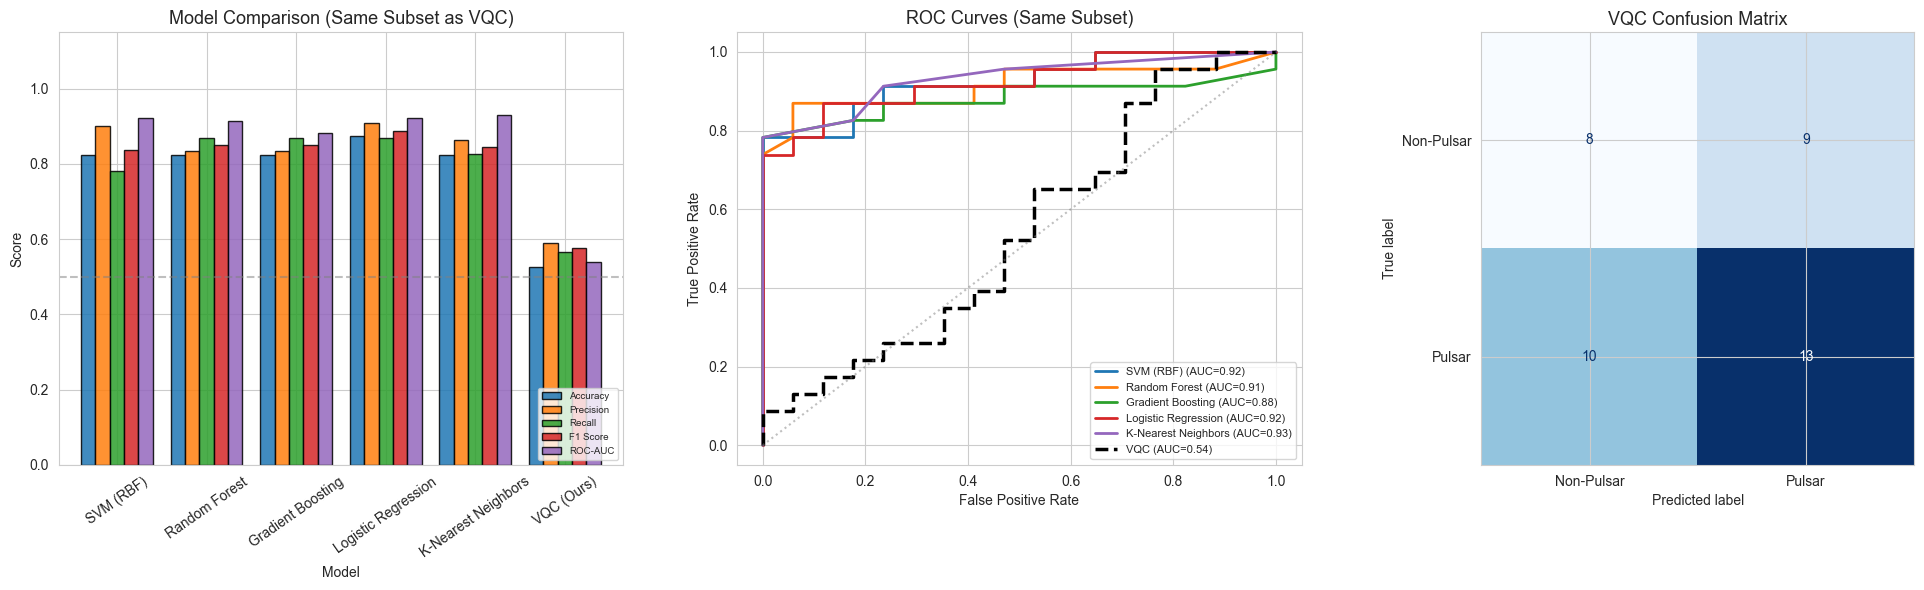

In [12]:
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Metric comparison bar chart (same subset) ---
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
df_plot = df_small[metrics_to_plot]
df_plot.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='black', alpha=0.85)
axes[0].set_title('Model Comparison (Same Subset as VQC)', fontsize=13)
axes[0].set_ylabel('Score')
axes[0].set_ylim([0, 1.15])
axes[0].legend(fontsize=7, loc='lower right')
axes[0].tick_params(axis='x', rotation=35)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# --- Plot 2: ROC curves on the small subset ---
for name, model in classical_models.items():
    model.fit(X_train_q, Y_train_q)
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test_q)[:, 1]
    else:
        probs = model.decision_function(X_test_q)
    fpr, tpr, _ = roc_curve(Y_test_q, probs)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.2f})')

# VQC ROC
fpr_q, tpr_q, _ = roc_curve(Y_test_q, test_probs_q)
axes[1].plot(fpr_q, tpr_q, 'k--', linewidth=2.5, label=f'VQC (AUC={auc(fpr_q, tpr_q):.2f})')
axes[1].plot([0, 1], [0, 1], 'gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (Same Subset)', fontsize=13)
axes[1].legend(fontsize=8)

# --- Plot 3: VQC Confusion matrix ---
cm_q = confusion_matrix(Y_test_q, test_preds_q)
disp = ConfusionMatrixDisplay(cm_q, display_labels=['Non-Pulsar', 'Pulsar'])
disp.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('VQC Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.show()

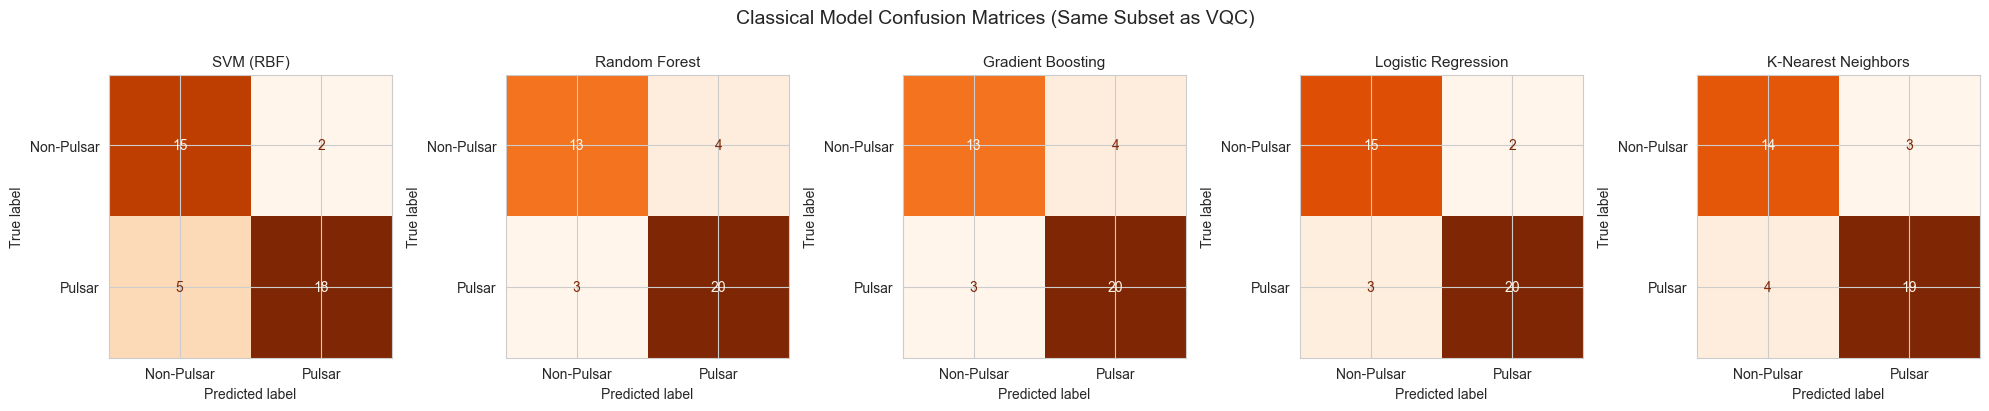

In [13]:
# Confusion matrices for all classical models (small subset)
n_models = len(classical_models)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

for ax, (name, model) in zip(axes, classical_models.items()):
    model.fit(X_train_q, Y_train_q)
    preds = model.predict(X_test_q)
    cm = confusion_matrix(Y_test_q, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Pulsar', 'Pulsar'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(name, fontsize=11)

plt.suptitle('Classical Model Confusion Matrices (Same Subset as VQC)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 9. Summary of Fixes & Findings

| Issue | Original | Fixed |
|-------|----------|-------|
| Data leakage | Scaler fit on full data before split | Scaler fit on train only |
| Ansatz depth | 1 layer, Ry only, no entanglement | 2 layers, Ry+Rz, CNOT ring |
| Measurement | Only qubit 0 (7 qubits wasted) | All 8 qubits (parity output) |
| Gradients | Finite differences (δ=0.01), noisy | Parameter-shift rule (exact) |
| Initialization | `np.ones(N)` (all identical) | `np.random.uniform(0, 2π)` |
| Backend | Re-created every circuit call | Created once, reused |
| Shuffling | Same order every epoch | Random permutation each epoch |
| Gradient redundancy | `pred2` recomputed N times | Eliminated via shift rule |
| Array copy | `copy.copy()` (fragile) | `np.copy()` / `.copy()` |
| `df.corr()` | Missing `numeric_only` | Added `numeric_only=True` |
| Metrics | Accuracy only | Accuracy, Precision, Recall, F1, ROC-AUC, MCC, Balanced Acc |
| Classical baselines | Default params, no CV | 5 models, cross-validation, fair subset comparison |